In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
customers = pd.read_csv("ecommerce-sales-analysis/customers.csv")
orders = pd.read_csv("ecommerce-sales-analysis/orders.csv")
order_items = pd.read_csv("ecommerce-sales-analysis/order_items.csv")
products = pd.read_csv("ecommerce-sales-analysis/products.csv")

In [3]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

Customers: (3600, 4)
Orders: (9245, 7)
Order Items: (15608, 5)
Products: (90, 5)


In [4]:
# Data Exploration: customers
customers.head()

,customer_id,signup_date,state,acquisition_channel
0,1,2024-09-13,CO,organic_search
1,2,2025-10-21,IL,paid_search
2,3,2025-01-17,AZ,referral
3,4,2024-06-23,FL,paid_social
4,5,2025-04-08,IL,paid_social


In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          3600 non-null   int64
 1   signup_date          3600 non-null   str  
 2   state                3600 non-null   str  
 3   acquisition_channel  3600 non-null   str  
dtypes: int64(1), str(3)
memory usage: 193.1 KB


In [6]:
# check the number of unique customer_id
customers['customer_id'].nunique()

3600

In [7]:
# check whether customer_ids are unique
customers['customer_id'].is_unique

True

In [8]:
customers.isna().sum()

customer_id            0
signup_date            0
state                  0
acquisition_channel    0
dtype: int64

In [9]:
customers.duplicated().sum()

np.int64(0)

In [10]:
# Data Exploration: products
products.head()

,product_id,product_name,category,list_price,unit_cost
0,1001,Brass Chef Knife,Kitchen,61.99,38.13
1,1002,Walnut Cutting Board,Kitchen,138.99,74.76
2,1003,Matte Black Dutch Oven,Kitchen,22.99,13.50
3,1004,Classic Skillet,Kitchen,75.99,39.86
4,1005,Linen Mixing Bowl Set,Kitchen,79.99,41.11


In [11]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     int64  
 1   product_name  90 non-null     str    
 2   category      90 non-null     str    
 3   list_price    90 non-null     float64
 4   unit_cost     90 non-null     float64
dtypes: float64(2), int64(1), str(2)
memory usage: 5.9 KB


In [12]:
# check the number of unique product_id
products["product_id"].nunique()

90

In [13]:
# check whether all product_ids are unique
products["product_id"].is_unique

True

In [14]:
products.duplicated().sum()

np.int64(0)

In [15]:
products[["list_price", "unit_cost"]].describe()

,list_price,unit_cost
count,90.000000,90.000000
mean,134.378889,69.563222
std,136.899512,76.820180
min,7.990000,4.760000
25%,52.490000,24.547500
50%,95.490000,49.275000
75%,151.490000,74.330000
max,773.990000,445.470000


In [16]:
(products["list_price"] < 0).sum()

np.int64(0)

In [17]:
(products["unit_cost"] < 0).sum()

np.int64(0)

In [18]:
# Data Exploration: orders
orders.head()

,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
0,100001,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95
1,100002,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00
2,100003,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00
3,100004,725,2024-01-01 12:48:34,completed,apple_pay,WELCOME10,0.00
4,100005,3452,2024-01-01 17:44:03,completed,gift_card,NaN,0.00


In [19]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 9245 entries, 0 to 9244
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        9245 non-null   int64  
 1   customer_id     9245 non-null   int64  
 2   order_date      9245 non-null   str    
 3   status          9245 non-null   str    
 4   payment_method  9245 non-null   str    
 5   discount_code   1411 non-null   str    
 6   shipping_fee    9245 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 857.0 KB


In [20]:
orders["order_id"].nunique()

9207

In [21]:
orders["order_id"].is_unique

False

In [22]:
# Check for duplicate order_id
orders[orders["order_id"].duplicated(keep=False)].sort_values("order_id")

,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
47,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95
8560,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95
7556,100303,853,2024-02-03 08:33:22,completed,apple_pay,NaN,0.00
303,100303,853,2024-02-03 08:33:22,completed,apple_pay,NaN,0.00
5488,100710,526,2024-03-13 13:39:17,completed,credit_card,NaN,0.00
...,...,...,...,...,...,...,...
8617,108585,1995,2025-11-28 12:43:37,completed,apple_pay,HOLIDAY20,0.00
9104,109068,1981,2025-12-20 13:27:25,completed,credit_card,HOLIDAY20,6.95
3104,109068,1981,2025-12-20 13:27:25,completed,credit_card,HOLIDAY20,6.95
4213,109087,3358,2025-12-22 08:35:44,completed,credit_card,HOLIDAY20,0.00


In [23]:
# Checking for exact duplicate records
orders[orders["order_id"].duplicated(keep=False)].duplicated().sum()

np.int64(38)

In [24]:
orders.duplicated().sum()

np.int64(38)

In [25]:
orders["status"].value_counts()

status
completed    8490
returned      409
canceled      346
Name: count, dtype: int64

In [26]:
orders["payment_method"].value_counts()

payment_method
credit_card    5332
paypal         1959
apple_pay      1422
gift_card       532
Name: count, dtype: int64

In [27]:
orders["discount_code"].value_counts(dropna=False)

discount_code
NaN          7834
HOLIDAY20     782
WELCOME10     391
SPRING15      238
Name: count, dtype: int64

In [28]:
orders["shipping_fee"].describe()

count    9245.000000
mean        1.544862
std         2.889826
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         6.950000
Name: shipping_fee, dtype: float64

In [29]:
(orders["shipping_fee"] < 0).sum()

np.int64(0)

In [30]:
# Data Exploration: order_items
order_items.shape

(15608, 5)

In [31]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount_amount
0,100001,1031,1,38.99,0.0
1,100002,1087,1,45.99,0.0
2,100002,1072,1,141.99,0.0
3,100003,1048,1,139.99,0.0
4,100004,1083,1,19.99,2.0


In [32]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 15608 entries, 0 to 15607
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         15608 non-null  int64  
 1   product_id       15608 non-null  int64  
 2   quantity         15608 non-null  int64  
 3   unit_price       15409 non-null  float64
 4   discount_amount  15608 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 609.8 KB


In [33]:
order_items["order_id"].nunique()

9207

In [34]:
order_items["product_id"].nunique()

90

In [35]:
order_items["order_id"].value_counts().head(10)

order_id
100029    4
100035    4
100041    4
100042    4
100046    4
100088    4
100092    4
100120    4
100122    4
100133    4
Name: count, dtype: int64

In [36]:
order_items.duplicated().sum()

np.int64(0)

In [37]:
order_items.isna().sum()

order_id             0
product_id           0
quantity             0
unit_price         199
discount_amount      0
dtype: int64

In [38]:
order_items[order_items["unit_price"].isna()].head()

,order_id,product_id,quantity,unit_price,discount_amount
55,100033,1086,1,NaN,0.0
110,100062,1020,1,NaN,0.0
197,100116,1087,2,NaN,0.0
366,100210,1014,1,NaN,0.0
626,100361,1077,1,NaN,0.0


In [39]:
(order_items["quantity"] <= 0).sum()

np.int64(0)

In [40]:
(order_items["unit_price"] < 0).sum()

np.int64(0)

In [41]:
(order_items["discount_amount"] < 0).sum()

np.int64(0)

##  Relationship & Referential Integrity

After examining each table individually, I will now validate the relationships between the tables.

The main relationships to verify are:

- `customers.customer_id` → `orders.customer_id`
- `orders.order_id` → `order_items.order_id`
- `products.product_id` → `order_items.product_id`

In [42]:
# Check whether every customer referenced in orders exists in customers
orders["customer_id"].isin(customers["customer_id"]).value_counts()

customer_id
True    9245
Name: count, dtype: int64

In [43]:
# Check whether every order_id in order_items exists in orders
order_items["order_id"].isin(orders["order_id"]).value_counts()

order_id
True    15608
Name: count, dtype: int64

In [44]:
# Check whether every product_id in order_items exists in products
order_items["product_id"].isin(products["product_id"]).value_counts()

product_id
True    15608
Name: count, dtype: int64

## Data Understanding — Key Observations

* 3,600 customers and 90 products with unique IDs and no missing records.
* 9,245 order records representing 9,207 unique orders; 38 exact duplicate records identified.
* 15,608 order-item records with 199 missing `unit_price` values.
* All key relationships between customers, orders, order items, and products are valid.
* Main data-quality issues: duplicate orders, missing item prices, and date fields stored as text.


## Data Cleaning

The following data-quality issues identified during the data-understanding stage will be addressed:

1. Duplicate records in `orders`
2. Missing `unit_price` values in `order_items`
3. Date columns stored as text
4. Missing `discount_code` values
5. Final data-quality validation


In [45]:
# Check duplicate records in orders
orders.duplicated().sum()

np.int64(38)

In [46]:
# Remove exact duplicate orders
orders = orders.drop_duplicates()
orders.duplicated().sum()

np.int64(0)

In [47]:
# Find missing unit_price values in order_items
order_items["unit_price"].isna().sum()

np.int64(199)

In [48]:
# Find the percentage of missing unit_price
round(order_items["unit_price"].isna().mean() * 100, 2)

np.float64(1.27)

In [49]:
# Drop those missing unit_price
order_items = order_items.dropna(subset=["unit_price"])
order_items["unit_price"].isna().sum()

np.int64(0)

In [50]:
# Convert the date columns
orders["order_date"] = pd.to_datetime(orders["order_date"], errors= "coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors= "coerce")

In [51]:
orders.dtypes
customers.dtypes

customer_id                     int64
signup_date            datetime64[us]
state                             str
acquisition_channel               str
dtype: object

In [52]:
# Replace missing discount_code with "No Discount"
orders["discount_code"] = orders["discount_code"].fillna("No Discount")
orders["discount_code"].value_counts(dropna=False)

discount_code
No Discount    7802
HOLIDAY20       778
WELCOME10       389
SPRING15        238
Name: count, dtype: int64

In [53]:
# Standardize the category names in products
products["category"] = products["category"].str.strip().str.title()

products["category"].value_counts()

category
Kitchen      15
Bedding      12
Furniture    12
Decor        12
Outdoor      11
Bath         10
Lighting      9
Storage       9
Name: count, dtype: int64

In [54]:
# Final Data-Quality Validation

#Check the table sizes
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

Customers: (3600, 4)
Orders: (9207, 7)
Order Items: (15409, 5)
Products: (90, 5)


In [55]:
# Check duplicates
print("Duplicate customers:", customers.duplicated().sum())
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate order items:", order_items.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())

Duplicate customers: 0
Duplicate orders: 0
Duplicate order items: 0
Duplicate products: 0


In [56]:
# Check missing values
print("Missing customer values:")
print(customers.isna().sum())

print("\nMissing order values:")
print(orders.isna().sum())

print("\nMissing order-item values:")
print(order_items.isna().sum())

print("\nMissing product values:")
print(products.isna().sum())

Missing customer values:
customer_id            0
signup_date            0
state                  0
acquisition_channel    0
dtype: int64

Missing order values:
order_id          0
customer_id       0
order_date        0
status            0
payment_method    0
discount_code     0
shipping_fee      0
dtype: int64

Missing order-item values:
order_id           0
product_id         0
quantity           0
unit_price         0
discount_amount    0
dtype: int64

Missing product values:
product_id      0
product_name    0
category        0
list_price      0
unit_cost       0
dtype: int64


## Create Derived Metrics: Revenue, Cost, Profit

In [57]:
# Bring unit_cost from products into order_items
order_items = order_items.merge(
    products[["product_id", "unit_cost"]],
    on="product_id",
    how="left"
)

order_items

,order_id,product_id,quantity,unit_price,discount_amount,unit_cost
0,100001,1031,1,38.99,0.00,20.19
1,100002,1087,1,45.99,0.00,20.30
2,100002,1072,1,141.99,0.00,62.78
3,100003,1048,1,139.99,0.00,71.41
4,100004,1083,1,19.99,2.00,9.51
...,...,...,...,...,...,...
15404,109204,1070,1,129.14,25.83,51.74
15405,109205,1072,2,149.09,0.00,62.78
15406,109206,1071,1,10.49,0.00,5.84
15407,109207,1023,2,142.79,57.12,60.49


In [58]:
order_items["revenue"] = (order_items["quantity"] * order_items["unit_price"]) - order_items["discount_amount"]
order_items["cost"] = order_items["quantity"] * order_items["unit_cost"]
order_items["profit"] = order_items["revenue"] - order_items["cost"]

order_items

,order_id,product_id,quantity,unit_price,discount_amount,unit_cost,revenue,cost,profit
0,100001,1031,1,38.99,0.00,20.19,38.99,20.19,18.80
1,100002,1087,1,45.99,0.00,20.30,45.99,20.30,25.69
2,100002,1072,1,141.99,0.00,62.78,141.99,62.78,79.21
3,100003,1048,1,139.99,0.00,71.41,139.99,71.41,68.58
4,100004,1083,1,19.99,2.00,9.51,17.99,9.51,8.48
...,...,...,...,...,...,...,...,...,...
15404,109204,1070,1,129.14,25.83,51.74,103.31,51.74,51.57
15405,109205,1072,2,149.09,0.00,62.78,298.18,125.56,172.62
15406,109206,1071,1,10.49,0.00,5.84,10.49,5.84,4.65
15407,109207,1023,2,142.79,57.12,60.49,228.46,120.98,107.48


## Exploratory Plots

In [59]:
# Bring order_date from orders in order_items
order_items_eda = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

# Calculate monthly revenue
monthly_revenue = (
    order_items_eda
    .groupby(order_items_eda["order_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue

order_date
2024-01     61835.60
2024-02     66811.35
2024-03     77617.06
2024-04     69247.95
2024-05     81418.16
2024-06     72056.04
2024-07     84294.91
2024-08     67663.46
2024-09     71244.45
2024-10     69844.83
2024-11    107507.48
2024-12     96962.49
2025-01     78143.35
2025-02     75430.60
2025-03     85946.54
2025-04     86177.99
2025-05     90989.39
2025-06    100794.63
2025-07     91074.58
2025-08     99330.73
2025-09     82579.54
2025-10     90329.70
2025-11    141099.04
2025-12     98914.12
Freq: M, Name: revenue, dtype: float64

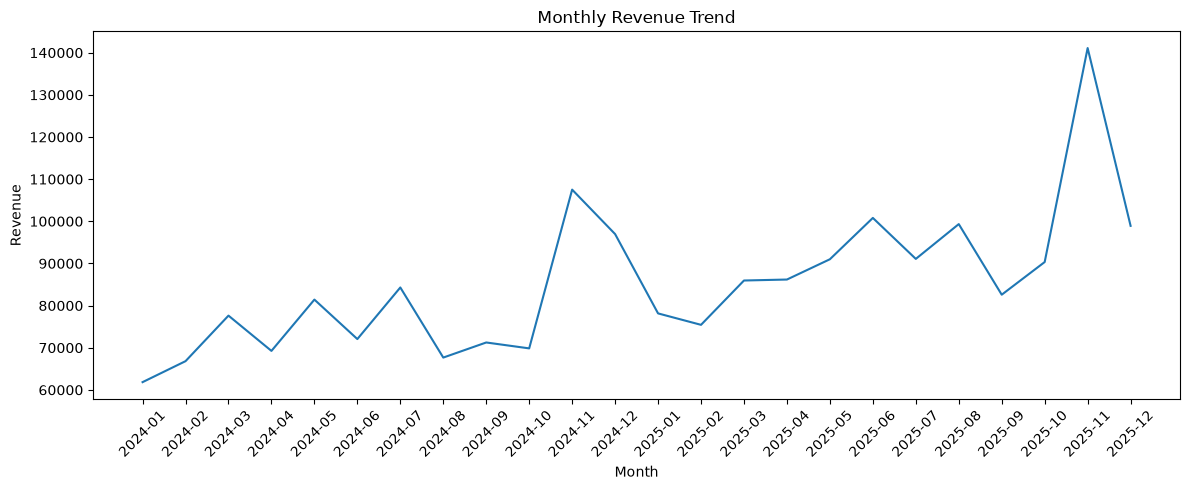

In [60]:
# Monthly Revenue Trend 
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
monthly_orders = (
    orders
    .groupby(orders["order_date"].dt.to_period("M"))["order_id"]
    .nunique()
)

monthly_orders

order_date
2024-01    287
2024-02    293
2024-03    324
2024-04    317
2024-05    338
2024-06    327
2024-07    350
2024-08    318
2024-09    288
2024-10    332
2024-11    558
2024-12    480
2025-01    330
2025-02    327
2025-03    385
2025-04    398
2025-05    405
2025-06    408
2025-07    376
2025-08    405
2025-09    369
2025-10    411
2025-11    670
2025-12    511
Freq: M, Name: order_id, dtype: int64

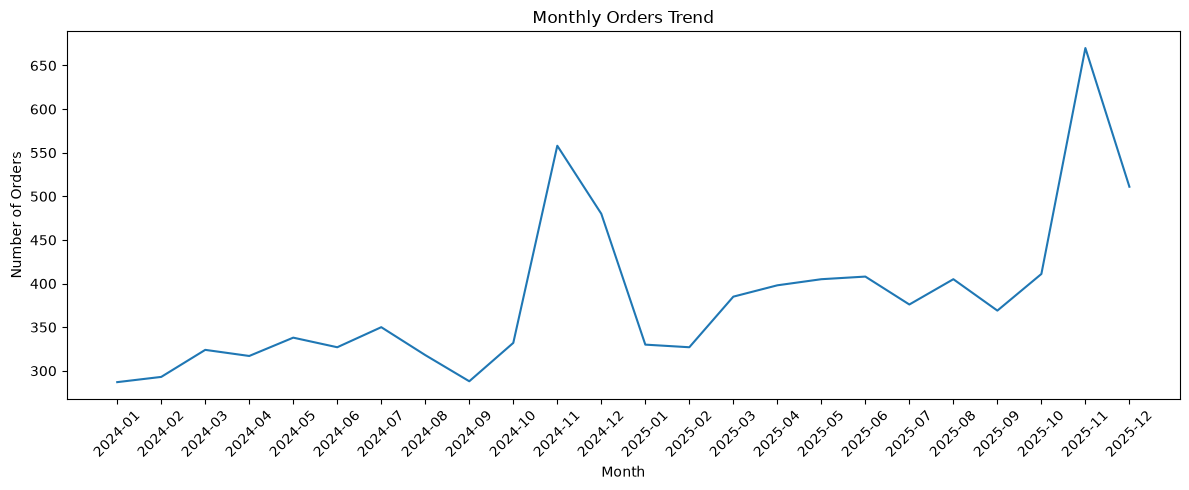

In [62]:
# Monthly Orders Trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders.index.astype(str), monthly_orders.values)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# Bring category into order_items_eda
order_items_eda = order_items_eda.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

order_items_eda.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'unit_cost', 'revenue', 'cost', 'profit', 'order_date', 'category'],
      dtype='str')

In [64]:
# Calculate revenue by category
revenue_by_category = (
    order_items_eda
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
revenue_by_category

category
Furniture    367852.11
Kitchen      301330.45
Decor        300056.43
Bedding      289352.35
Outdoor      270559.53
Lighting     251863.08
Storage      148643.90
Bath         117656.14
Name: revenue, dtype: float64

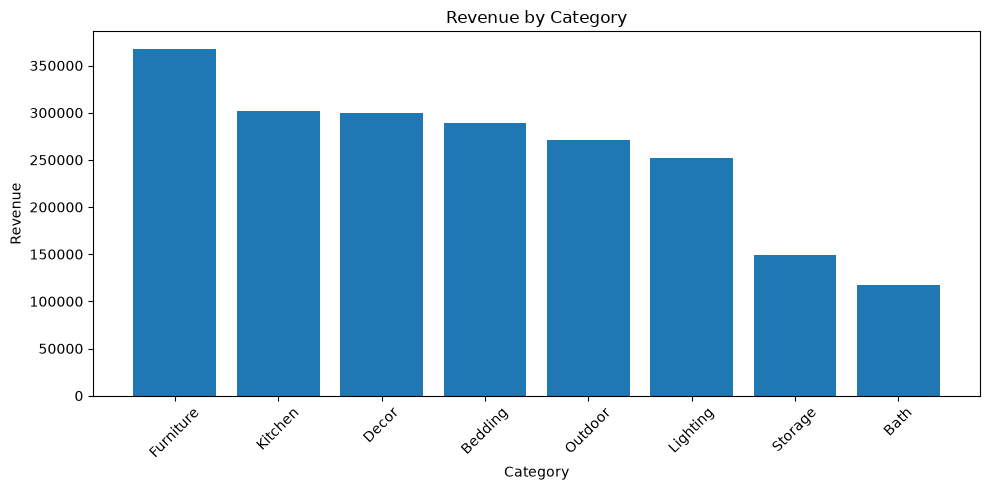

In [65]:
# Total Revenue by Category
plt.figure(figsize=(10, 5))
plt.bar(revenue_by_category.index, revenue_by_category.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
# Calculate Profit by Category
profit_by_category = (
    order_items_eda
    .groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)
profit_by_category

category
Furniture    170306.95
Decor        153729.50
Bedding      148239.17
Kitchen      142521.19
Outdoor      135052.49
Lighting     119535.43
Storage       82636.81
Bath          55156.95
Name: profit, dtype: float64

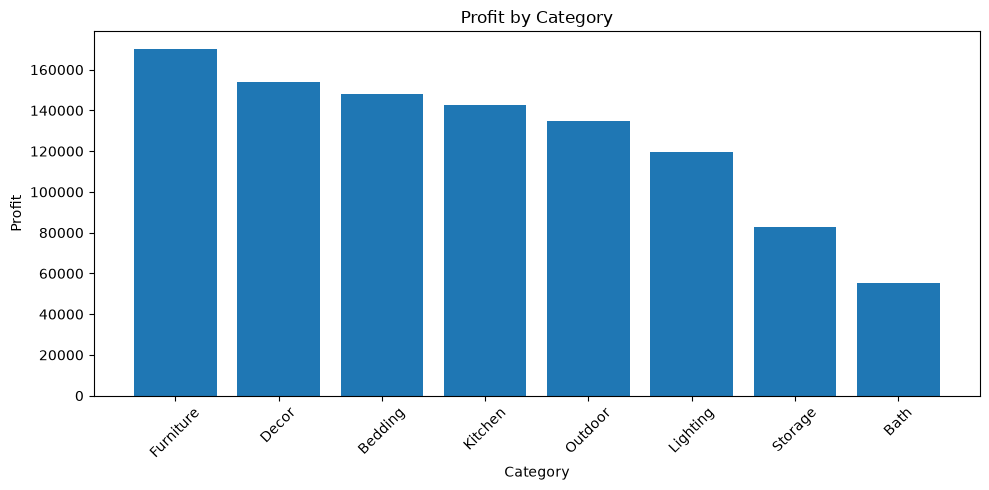

In [67]:
# Total Profit by Category
plt.figure(figsize=(10, 5))
plt.bar(profit_by_category.index, profit_by_category.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

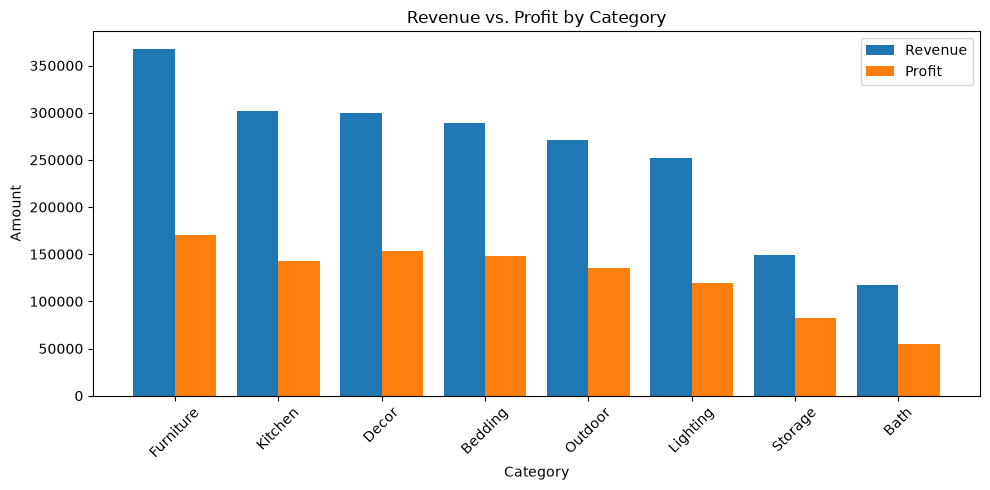

In [68]:
# Compare total revenue and profit by product category

x = range(len(revenue_by_category))

plt.figure(figsize=(10, 5))
plt.bar(x, revenue_by_category.values, width=0.4, label="Revenue")
plt.bar([i + 0.4 for i in x], profit_by_category[revenue_by_category.index].values, width=0.4, label="Profit")

plt.title("Revenue vs. Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks([i + 0.2 for i in x], revenue_by_category.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# Bring product_name in order_items_eda
order_items_eda = order_items_eda.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)
# Calculate revenue by product
product_revenue = (
    order_items_eda
    .groupby(["product_id", "product_name"])["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
product_revenue

product_id  product_name             
1059        Cotton Patio Chair           74461.90
1042        Classic Dining Chair Pair    59719.14
1072        Coastal Picture Frame Set    47657.93
1041        Nordic Side Table            45961.79
1040        Marble Bookshelf             45225.82
1044        Bamboo Nightstand            44543.02
1018        Ceramic Quilt                44446.23
1076        Modern Wreath                43522.33
1080        Classic Garland              42899.86
1054        Velvet String Lights         40448.35
Name: revenue, dtype: float64

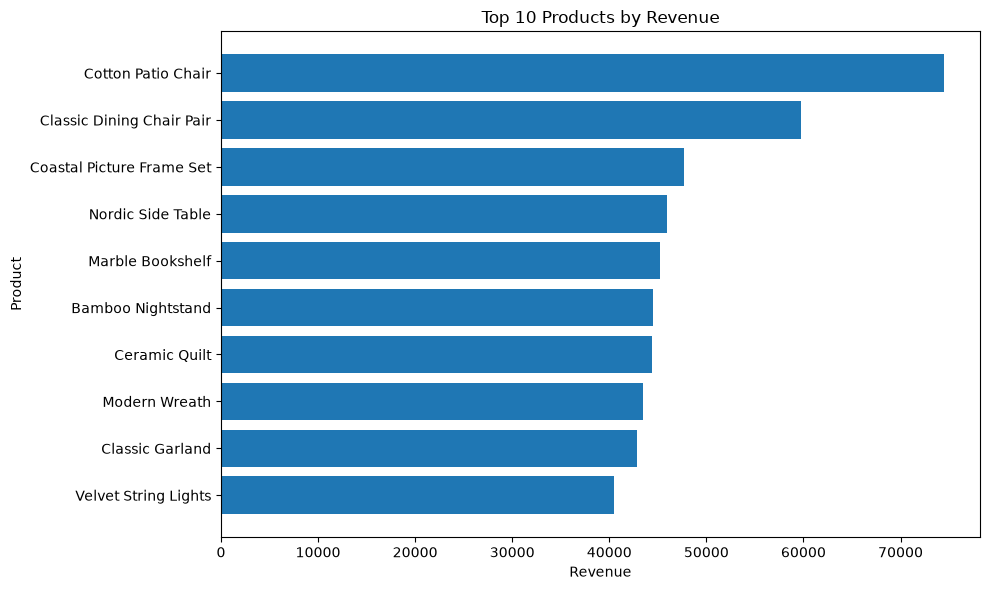

In [71]:
# Top 10 products by revenue
plt.figure(figsize=(10, 6))
plt.barh(product_revenue.index.get_level_values("product_name")[::-1],
         product_revenue.values[::-1])

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [72]:
# Calculate orders by status
orders_by_status = orders["status"].value_counts()
orders_by_status

status
completed    8456
returned      407
canceled      344
Name: count, dtype: int64

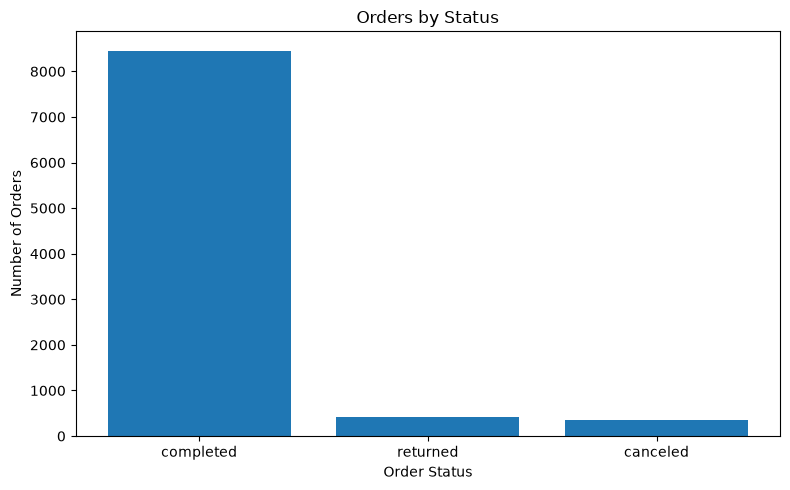

In [73]:
# Number of orders by status
plt.figure(figsize=(8, 5))
plt.bar(orders_by_status.index, orders_by_status.values)
plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [74]:
# Bring status from orders in order_items_eda
order_items_eda = order_items_eda.merge(
    orders[["order_id", "status"]],
    on="order_id",
    how="left"
)

# Remove duplicate order-category combinations
order_category = (
    order_items_eda[["order_id", "category", "status"]]
    .drop_duplicates()
)
order_category.head()

,order_id,category,status
0,100001,Bath,completed
1,100002,Storage,completed
2,100002,Decor,completed
3,100003,Furniture,completed
4,100004,Storage,completed


In [75]:
# Calculate return and cancellation rates
category_status = pd.crosstab(
    order_category["category"],
    order_category["status"]
)

category_status["return_rate"] = (
    category_status["returned"] / category_status.sum(axis=1) * 100
)

category_status["cancellation_rate"] = (
    category_status["canceled"] / category_status.sum(axis=1) * 100
)

category_status[["return_rate", "cancellation_rate"]].sort_values(
    "return_rate",
    ascending=False
)

status,return_rate,cancellation_rate
category,,
Furniture,11.658291,3.079496
Bedding,5.002811,3.251116
Bath,4.371921,4.483005
Outdoor,4.351088,3.738734
Kitchen,4.196302,3.799451
Decor,4.154303,3.444248
Storage,4.093567,3.267033
Lighting,3.963666,2.963052


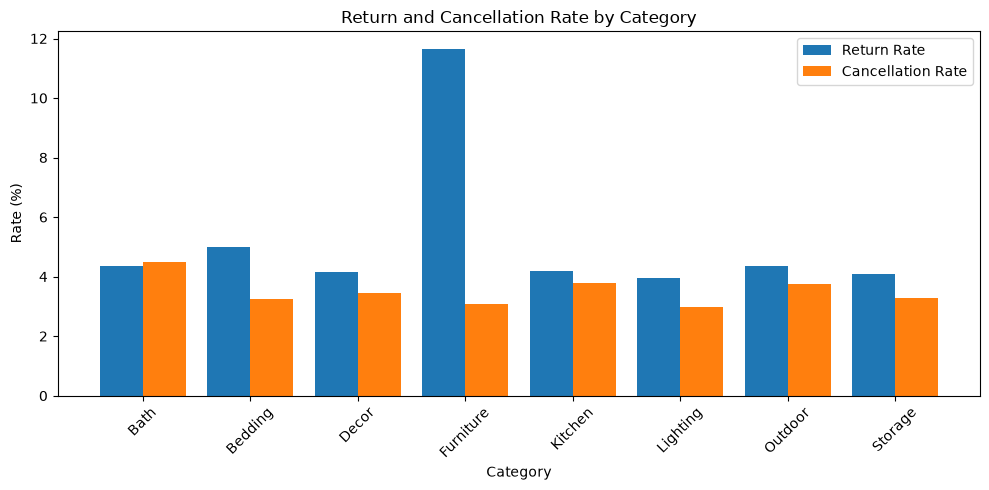

In [76]:
# Compare return and cancellation rates by product category
category_rates = category_status[["return_rate", "cancellation_rate"]]

x = range(len(category_rates))

plt.figure(figsize=(10, 5))
plt.bar(
    x,
    category_rates["return_rate"],
    width=0.4,
    label="Return Rate"
)
plt.bar(
    [i + 0.4 for i in x],
    category_rates["cancellation_rate"],
    width=0.4,
    label="Cancellation Rate"
)

plt.title("Return and Cancellation Rate by Category")
plt.xlabel("Category")
plt.ylabel("Rate (%)")
plt.xticks(
    [i + 0.2 for i in x],
    category_rates.index,
    rotation=45
)
plt.legend()
plt.tight_layout()
plt.show()

## EDA Summary and Key Insights

The exploratory and SQL-based analysis identified the following key patterns across sales performance, profitability, products, categories, returns, and cancellations.

### Q1 — Sales Performance Over Time

* Revenue increased by **21.0%** from 2024 to 2025.
* Profit increased by **27.7%** from 2024 to 2025.
* Profit margin increased from **47.75% in 2024 to 50.39% in 2025**.
* **November** was the strongest month for revenue and order volume in both years.

### Q2 — Product and Category Performance

* **Furniture** generated the highest total revenue and profit among the product categories.
* **Storage** had the highest category profit margin at **55.59%**.
* **Cotton Patio Chair** generated the highest product revenue and profit.
* Products with high revenue did not always have the highest profit margins.

### Q3 — Returns and Cancellations

* **407 of 9,207 orders were returned**, resulting in an overall return rate of **4.42%**.
* **344 of 9,207 orders were canceled**, resulting in an overall cancellation rate of **3.74%**.
* **Furniture** had the highest category return rate at **11.66%**.
* **Bath** had the highest category cancellation rate at **4.50%**.



In [78]:
order_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'unit_cost', 'revenue', 'cost', 'profit'],
      dtype='str')

In [79]:
order_items_clean = order_items[
    [
        "order_id",
        "product_id",
        "quantity",
        "unit_price",
        "discount_amount"
    ]
].copy()

order_items_clean.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount'], dtype='str')

In [80]:
# Save all four cleaned tables
customers.to_csv("ecommerce-sales-analysis/customers_clean.csv", index=False)

orders.to_csv("ecommerce-sales-analysis/orders_clean.csv", index=False)

order_items_clean.to_csv("ecommerce-sales-analysis/order_items_clean.csv", index=False)

products.to_csv("ecommerce-sales-analysis/products_clean.csv", index=False)